In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

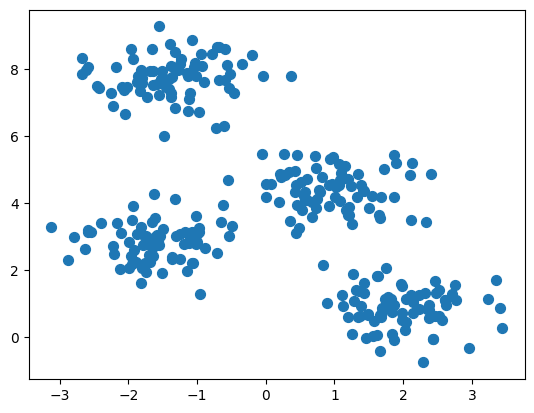

In [9]:
from sklearn.datasets import make_blobs
x,y_true=make_blobs(n_samples=300,centers=4,cluster_std=0.60,random_state=0)
plt.scatter(x[:,0],x[:,1],s=50);

In [10]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4)
kmeans.fit(x)
y_kmeans=kmeans.predict(x)

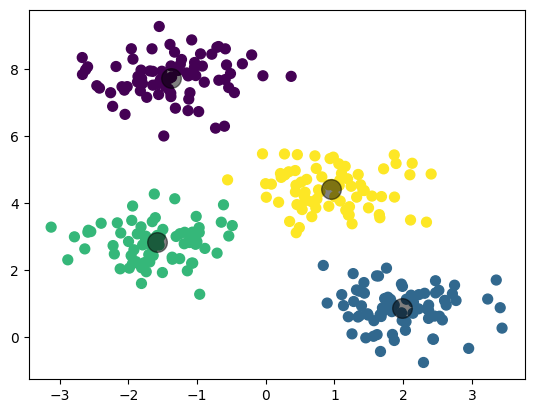

In [12]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(x, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(x.shape[0])[:n_clusters]
    centers = x[i]

    while True:
        # 2a. Assign labels based on closest center
        labels = pairwise_distances_argmin(x, centers)

        # 2b. Find new centers from means of points
        new_centers = np.array([x[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. Check for convergence
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(x, 4)
plt.scatter(x[:, 0], x[:, 1], c=y_kmeans, s=50, cmap='viridis')

plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

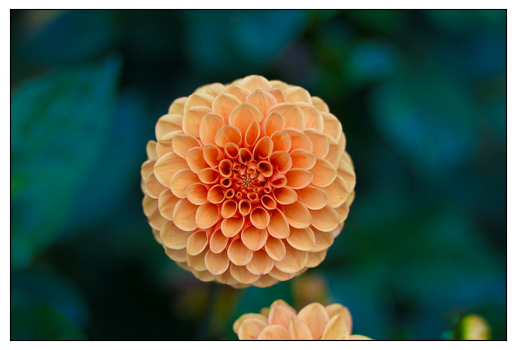

In [16]:
from sklearn.datasets import load_sample_image
china=load_sample_image("flower.jpg")
ax=plt.axes(xticks=[],yticks=[])
ax.imshow(china);

In [17]:
china.shape

(427, 640, 3)

In [18]:
data=china/255.0
data=data.reshape(427*640,3)
data.shape

(273280, 3)

In [19]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

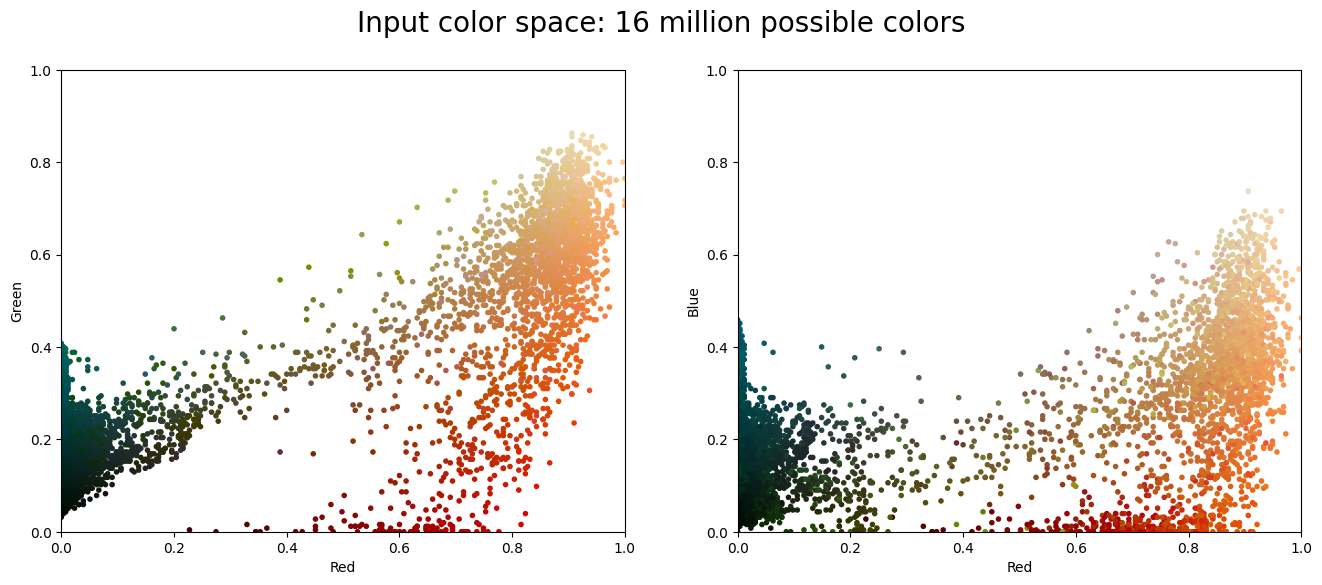

In [20]:
plot_pixels(data, title='Input color space: 16 million possible colors')

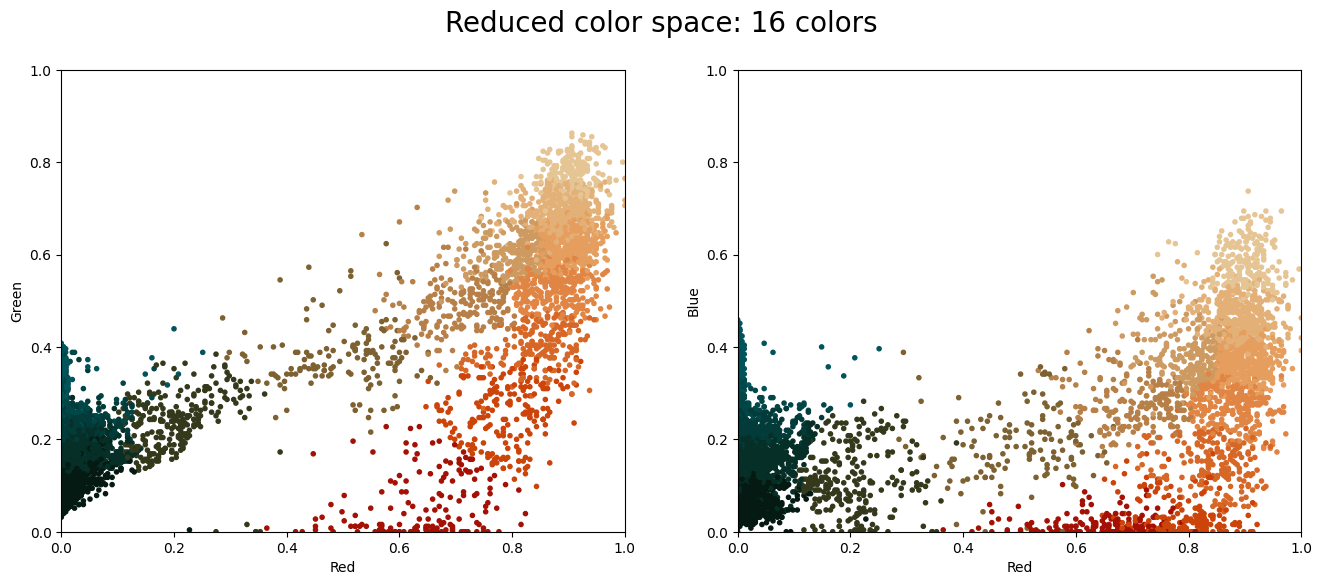

In [21]:
import warnings; warnings.simplefilter('ignore')

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,
            title="Reduced color space: 16 colors")

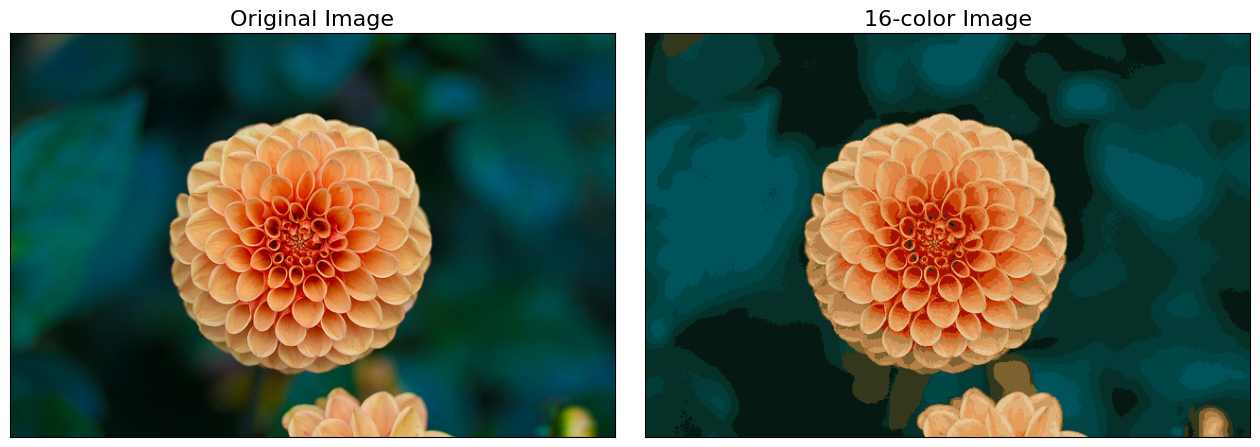

In [22]:
china_recolored = new_colors.reshape(china.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(china)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(china_recolored)
ax[1].set_title('16-color Image', size=16);

In [23]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score


cm = confusion_matrix(y_true, y_kmeans)

row_ind, col_ind = linear_sum_assignment(-cm)

matched_samples = cm[row_ind, col_ind].sum()

# Calculate the 'accuracy'
accuracy = matched_samples / len(y_true)

print(f"The 'accuracy' of the KMeans model (after optimal label mapping) is: {accuracy:.2f}")

ari = adjusted_rand_score(y_true, y_kmeans)
nmi = normalized_mutual_info_score(y_true, y_kmeans)

print(f"Adjusted Rand Index (ARI): {ari:.2f}")
print(f"Normalized Mutual Information (NMI): {nmi:.2f}")

The 'accuracy' of the KMeans model (after optimal label mapping) is: 1.00
Adjusted Rand Index (ARI): 1.00
Normalized Mutual Information (NMI): 1.00
